# Matrix Multiplication: X (4×6) × W (6×6)

This notebook demonstrates multiplying a matrix **X** of shape **(4, 6)** by a matrix **W** of shape **(6, 6)**.

**Rule:** For A × B to be valid, the number of columns in A must equal the number of rows in B.

- X: (4 × **6**) × W: (**6** × 6) → Result: **(4 × 6)**

In [1]:
import numpy as np

# Set a random seed for reproducibility
np.random.seed(42)

## 1. Create Matrix X (4 × 6)

In [2]:
X = np.random.randint(1, 10, size=(4, 6)).astype(float)

print(f"Matrix X — shape: {X.shape}")
print(X)

Matrix X — shape: (4, 6)
[[7. 4. 8. 5. 7. 3.]
 [7. 8. 5. 4. 8. 8.]
 [3. 6. 5. 2. 8. 6.]
 [2. 5. 1. 6. 9. 1.]]


## 2. Create Matrix W (6 × 6)

In [4]:
W = np.random.randint(1, 10, size=(6, 6)).astype(float)

print(f"Matrix W — shape: {W.shape}")
print(W)

Matrix W — shape: (6, 6)
[[3. 7. 4. 9. 3. 5.]
 [3. 7. 5. 9. 7. 2.]
 [4. 9. 2. 9. 5. 2.]
 [4. 7. 8. 3. 1. 4.]
 [2. 8. 4. 2. 6. 6.]
 [4. 6. 2. 2. 4. 8.]]


## 3. Multiply X × W

Three equivalent ways to do matrix multiplication in NumPy:

In [6]:
# Method 1: @ operator (recommended, Python 3.5+)
result_1 = X @ W

# Method 2: np.matmul
result_2 = np.matmul(X, W)

# Method 3: np.dot
result_3 = np.dot(X, W)

print("All three methods produce identical results:", np.allclose(result_1, result_2, result_3))

All three methods produce identical results: True


## 4. Inspect the Result

In [7]:
result = result_1

print(f"Result shape : {result.shape}  (expected: 4×6)")
print(f"\nResult (X @ W):")
print(result)

Result shape : (4, 6)  (expected: 4×6)

Result (X @ W):
[[111. 258. 138. 206. 148. 145.]
 [129. 290. 158. 224. 186. 189.]
 [ 95. 222. 112. 160. 150. 141.]
 [ 71. 178. 121. 110. 110. 108.]]


## 5. Manual Verification — First Element

result[0, 0] = dot product of **row 0 of X** and **column 0 of W**

In [8]:
manual_00 = np.dot(X[0, :], W[:, 0])

print(f"Row 0 of X       : {X[0, :]}")
print(f"Column 0 of W    : {W[:, 0]}")
print(f"Manual dot product : {manual_00}")
print(f"result[0, 0]       : {result[0, 0]}")
print(f"Match: {np.isclose(manual_00, result[0, 0])}")

Row 0 of X       : [7. 4. 8. 5. 7. 3.]
Column 0 of W    : [3. 3. 4. 4. 2. 4.]
Manual dot product : 111.0
result[0, 0]       : 111.0
Match: True


In [10]:
X[0,:]

array([7., 4., 8., 5., 7., 3.])

## 6. Visualise the Matrices with Matplotlib

/tmp/ipykernel_3530/3053224782.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


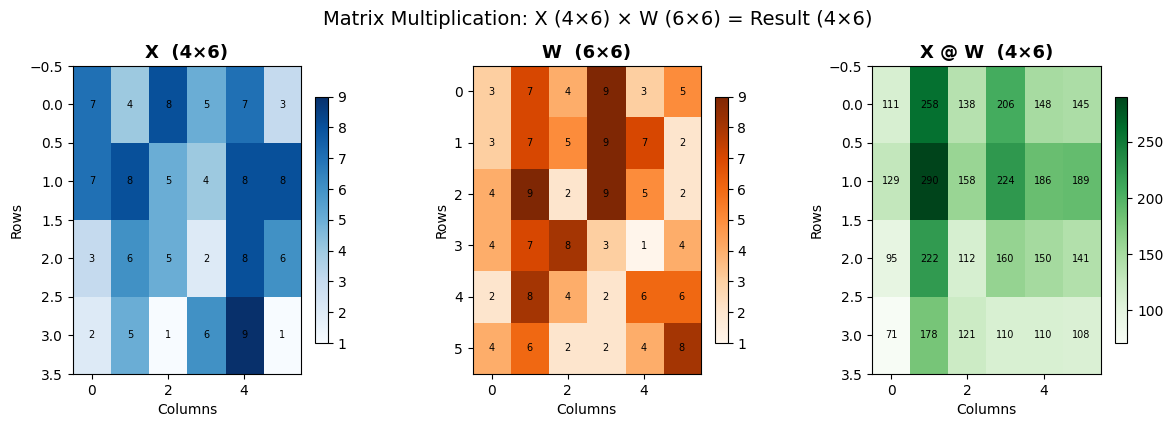

In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 4))
gs = gridspec.GridSpec(1, 3, wspace=0.4)

matrices = [(X, "X  (4×6)", "Blues"), (W, "W  (6×6)", "Oranges"), (result, "X @ W  (4×6)", "Greens")]

for i, (mat, title, cmap) in enumerate(matrices):
    ax = fig.add_subplot(gs[i])
    im = ax.imshow(mat, cmap=cmap, aspect="auto")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Columns")
    ax.set_ylabel("Rows")
    plt.colorbar(im, ax=ax, shrink=0.8)
    # Annotate each cell
    for r in range(mat.shape[0]):
        for c in range(mat.shape[1]):
            ax.text(c, r, f"{mat[r, c]:.0f}", ha="center", va="center", fontsize=7, color="black")

plt.suptitle("Matrix Multiplication: X (4×6) × W (6×6) = Result (4×6)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Summary

| Matrix | Shape | Description |
|--------|-------|-------------|
| X | 4 × 6 | Input matrix |
| W | 6 × 6 | Weight / transformation matrix |
| X @ W | **4 × 6** | Output — rows from X, cols from W |

> **Key rule:** `(m × k) @ (k × n)` → `(m × n)` — the inner dimensions must match.